# 01 Examples

In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.ticker import MaxNLocator
from scipy.integrate import simpson, trapezoid

from pytrunc.constant import DIR_ROOT
from pytrunc.phase import calc_hg_moments, calc_moments, henyey_greenstein
from pytrunc.truncation import delta_m_phase_approx, gt_phase_approx
from pytrunc.utils import integrate_lobatto, quadrature_lobatto

## Compute all truncated phase matrix unique terms

### Water cloud
- spherical particle

#### Get realistic water cloud phase function from mie calculation

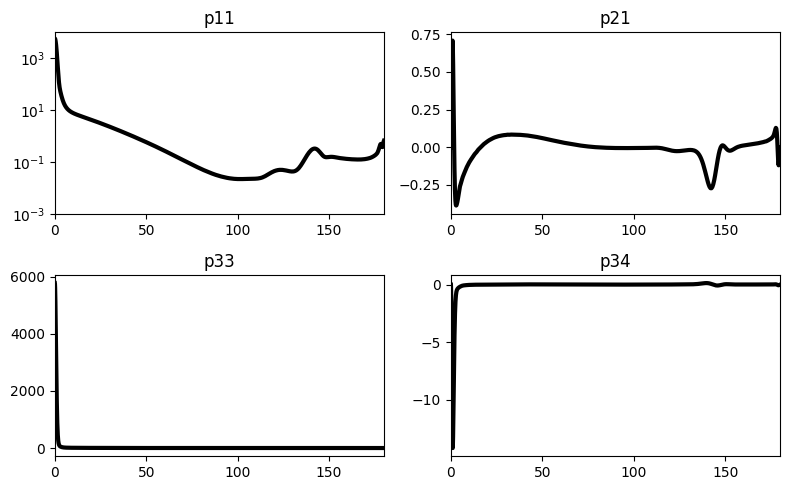

In [2]:
# in the paper (Iwabuchi et al. 2009) water cloud at wl = 500 nm and
# reff = 8 um

# wc available in smartg auxdata: https://github.com/hygeos/smartg
# Follow smartg README to download auxdata, then create the environment
# variable 'SMARTG_DIR_AUXDATA' where auxdata have been downloaded
# import os
# from pathlib import Path
# wc_path = Path(os.environ['SMARTG_DIR_AUXDATA']) / 'clouds/wc_sol.nc'
# ds = xr.open_dataset(wc_path)
# pha_exact = ds['phase'].interp(reff=8, wav=500,
#                                method='linear').values[0, :]

# wc at the correct wavelength and effective radius available in
# pytrunc/data
ds = xr.open_dataset(DIR_ROOT / 'pytrunc' / 'data' / 'wc_wl500_reff8.nc')

theta = ds['theta'].values
pha_ex = ds["phase"].values

method = 'lobatto'
# method = 'trapezoid'
# method = 'simpson' # use pair number for theta

INTEGRATORS = {
    "simpson": simpson,
    "trapezoid": trapezoid,
    "lobatto": integrate_lobatto
    }
integrate_m = INTEGRATORS[method]

# theta = np.linspace(0., 180., 18001)
# pha_ex = np.interp(theta, ds.theta.values, pha_ex)

# theta, _ = quadrature_lobatto(0., 180., 7201)
# pha_ex = np.interp(theta, ds.theta.values, pha_ex)

mu = np.cos(np.deg2rad(theta))
idmu = np.argsort(mu)


# renormalize depending on the chosen integration method
if method == 'lobatto':
    sin_th = np.sin(np.deg2rad(theta))
    pha_ex = (2. * pha_ex) / integrate_m(pha_ex[0,:]*sin_th, np.deg2rad(theta))
else:
    pha_ex = (2. * pha_ex) / integrate_m(pha_ex[0,idmu], mu[idmu])


fig, axs = plt.subplots(2, 2, figsize=(8,5))
axs = axs.ravel()
axs[0].plot(theta, pha_ex[0,:], 'k-', lw=3, label='p11 exact')
axs[0].set_yscale('log')
axs[0].set_ylim(1e-3, 1e4)
axs[0].set_xlim(0, 180)
axs[0].set_title('p11')
axs[1].plot(theta, pha_ex[1,:], 'k-', lw=3, label='p21 exact')
axs[1].set_xlim(0, 180)
axs[1].set_title('p21')
axs[2].plot(theta, pha_ex[2,:], 'k-', lw=3, label='p33 exact')
axs[2].set_xlim(0, 180)
axs[2].set_title('p33')
axs[3].plot(theta, pha_ex[3,:], 'k-', lw=3, label='p34 exact')
axs[3].set_xlim(0, 180)
axs[3].set_title('p34')
plt.tight_layout()
plt.show()

#### Truncated phase matrix using the GT method
- Iwabuchi 2009

f= 0.43294807007378455


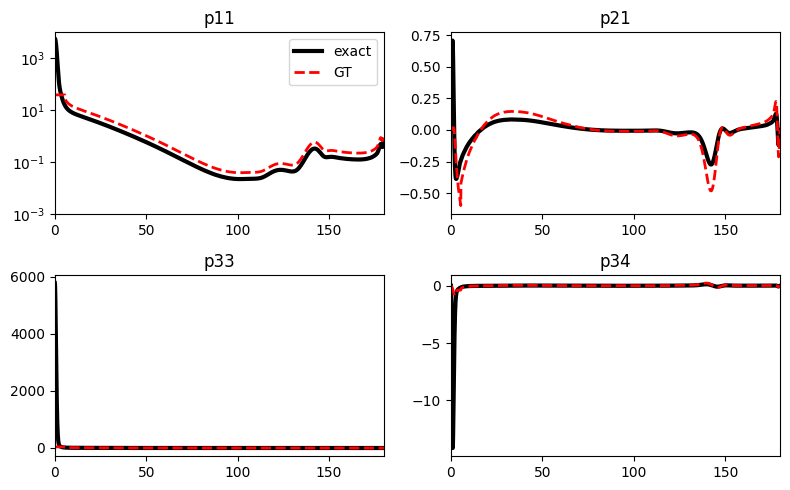

In [3]:
# Get the f value equal to chi_20
m_max = 20
chi = calc_moments(pha_ex[0,:], theta, m_max=m_max, normalize=True)
f = chi[m_max]
print('f=', f)

ds_gt = gt_phase_approx(pha_ex[0,:], theta, f, method=method,
                                        phase_moments_1=chi[1], th_tol=20.)

# Eq.5 in Waquet and Herman, 2019
pha_tr = np.zeros_like(pha_ex)
pha_tr[0,:] = ds_gt['phase_tr'].values
beta = (pha_tr[0,:] / pha_ex[0,:])
for i in range(1, pha_ex.shape[0]):
    pha_tr[i,:] = pha_ex[i,:] * beta

fig, axs = plt.subplots(2, 2, figsize=(8,5))
axs = axs.ravel()
axs[0].plot(theta, pha_ex[0,:], 'k-', lw=3, label='exact')
axs[0].plot(theta, pha_tr[0,:], 'r--', lw=2, label='GT')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].set_ylim(1e-3, 1e4)
axs[0].set_xlim(0, 180)
axs[0].set_title('p11')
axs[1].plot(theta, pha_ex[1,:], 'k-', lw=3)
axs[1].plot(theta, pha_tr[1,:], 'r--', lw=2)
axs[1].set_xlim(0, 180)
axs[1].set_title('p21')
axs[2].plot(theta, pha_ex[2,:], 'k-', lw=3)
axs[2].plot(theta, pha_tr[2,:], 'r--', lw=2)
# axs[2].set_yscale('log')
# axs[2].set_ylim(-1., 1)
axs[2].set_xlim(0, 180)
axs[2].set_title('p33')
axs[3].plot(theta, pha_ex[3,:], 'k-', lw=3)
axs[3].plot(theta, pha_tr[3,:], 'r--', lw=2)
axs[3].set_xlim(0, 180)
axs[3].set_title('p34')
plt.tight_layout()
#plt.savefig('truncated_phase_gt.png', dpi=300)

#### Truncated phase matrix using the delta-M method
- Wiscombe et al. 1997

f= 0.43294807007378455


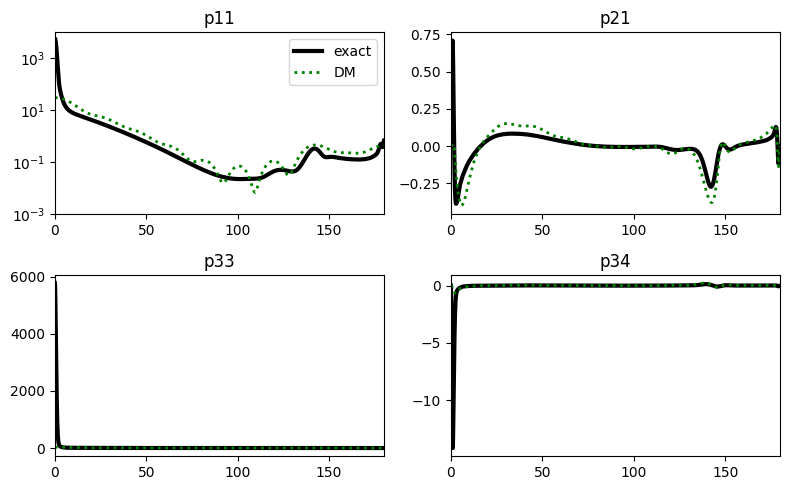

In [4]:
# Get the f value equal to chi_20
m_max = 20
ds_dm = delta_m_phase_approx(pha_ex[0,:], theta, m_max, method=method)
f = chi[m_max]
print('f=', f)

# Eq.5 in Waquet and Herman, 2019
pha_tr = np.zeros_like(pha_ex)
pha_tr[0,:] = ds_dm['phase_tr'].values
beta = (pha_tr[0,:] / pha_ex[0,:])
for i in range(1, pha_ex.shape[0]):
    pha_tr[i,:] = pha_ex[i,:] * beta

fig, axs = plt.subplots(2, 2, figsize=(8,5))
axs = axs.ravel()
axs[0].plot(theta, pha_ex[0,:], 'k-', lw=3, label='exact')
axs[0].plot(theta, pha_tr[0,:], 'g:', lw=2, label='DM')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].set_ylim(1e-3, 1e4)
axs[0].set_xlim(0, 180)
axs[0].set_title('p11')
axs[1].plot(theta, pha_ex[1,:], 'k-', lw=3)
axs[1].plot(theta, pha_tr[1,:], 'g:', lw=2)
axs[1].set_xlim(0, 180)
axs[1].set_title('p21')
axs[2].plot(theta, pha_ex[2,:], 'k-', lw=3)
axs[2].plot(theta, pha_tr[2,:], 'g:', lw=2)
axs[2].set_xlim(0, 180)
axs[2].set_title('p33')
# axs[2].set_yscale('log')
# axs[2].set_ylim(-1., 1)
axs[2].set_xlim(0, 180)
axs[2].set_title('p33')
axs[3].plot(theta, pha_ex[3,:], 'k-', lw=3)
axs[3].plot(theta, pha_tr[3,:], 'g:', lw=2)
axs[3].set_xlim(0, 180)
axs[3].set_title('p34')
plt.tight_layout()
#plt.savefig('truncated_phase_dm.png', dpi=300)

## Use Lobatto for an accurate phase function with lesser angle points
- Interesting for particles with a high forward or backward peak.
- A phase function with lesser angle points allows to save memory and
  computational time in some radiative transfer codes

### Example with the Henyey-Greentein phase function

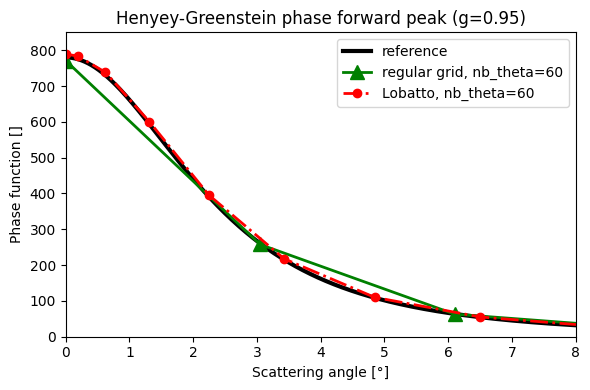

In [5]:
nb_th = 60
theta_lob, _ = quadrature_lobatto(0., 180., nb_th)
theta_reg = np.linspace(0, 180., nb_th)
hg_phase_lob = henyey_greenstein(theta_lob, g=0.95, normalize=2)
hg_phase_reg = henyey_greenstein(theta_reg, g=0.95, normalize=2)

theta_ref = np.linspace(0, 180., 18001)
hg_phase_ref = henyey_greenstein(theta_ref, g=0.95, normalize=2)

plt.figure(figsize=(6,4))
plt.plot(theta_ref, hg_phase_ref, 'k-', lw=3, label='reference')
plt.plot(theta_reg, hg_phase_reg, 'g-^', lw=2, ms=10,
         label=f'regular grid, nb_theta={nb_th}')
plt.plot(theta_lob, hg_phase_lob, 'r-.o', lw=2, ms=6,
         label=f'Lobatto, nb_theta={nb_th}')
plt.ylim(0, 850)
plt.xlim(0, 8)
plt.title('Henyey-Greenstein phase forward peak (g=0.95)')
plt.xlabel('Scattering angle [°]')
plt.ylabel('Phase function []')
plt.legend()
plt.tight_layout()
#plt.savefig('hg_phase_forward_peak.png', dpi=200)

### Example with moment calculations

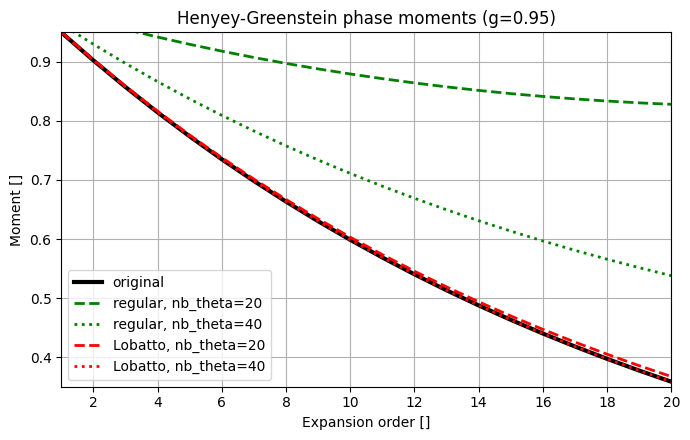

In [6]:
m_max = 20
chi_exact = calc_hg_moments(0.95, m_max)
nth = np.array([20, 40])
expansion_order = np.arange(0, m_max + 1)
marks = ['--', ':']


plt.figure(figsize=(7,4.5))
plt.plot(expansion_order, chi_exact, 'k-', lw=3, label='original')
for ith in range (len(nth)):
    theta_reg = np.linspace(0, 180., nth[ith])
    hg_reg = henyey_greenstein(theta_reg, g=0.95, normalize=2)
    chi_reg = calc_moments(hg_reg, theta_reg, m_max, method='trapezoid',
                           normalize=True)
    plt.plot(expansion_order, chi_reg, f'g{marks[ith]}', lw=2,
             label=f'regular, nb_theta={nth[ith]}')

for ith in range (len(nth)):
    theta_lob, _ = quadrature_lobatto(0., 180., nth[ith])
    hg_lob = henyey_greenstein(theta_lob, g=0.95, normalize=2)
    chi_lob = calc_moments(hg_lob, theta_lob, m_max, method='lobatto',
                           normalize=True)
    plt.plot(expansion_order, chi_lob, f'r{marks[ith]}', lw=2,
             label=f'Lobatto, nb_theta={nth[ith]}')

plt.title('Henyey-Greenstein phase moments (g=0.95)')
plt.xlabel('Expansion order []')
plt.ylabel('Moment []')
plt.ylim(0.35, 0.95)
plt.xlim(1, 20)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig('hg_phase_moments_convergence.png', dpi=200)